In [37]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, savgol_filter

In [46]:
file_path = r'N:\FWET\FDCH\AdsCatal\General\personal_work_folders\plasmacatdesign\co2-splitting\uhasselt\GM13.3\pwr-const\lissajous\70.0s-01-no-plasma\lissajous_data.parquet'

data = pd.read_parquet(file_path)

data.head()

,time_s,charge_C,voltage_V,current_reactor_A,current_source_A,shift_time_s,project_name,reaction_type,material_supplier,material_name,wattage_const,residence_time_s,measurement_number,plasma_state,date,psdata_file_name
0,0.000000e+00,-1.242618e-08,-157.4803,0.001181,0.003661,0.0,plasmacatdesign,co2-splitting,uhasselt,GM13.3,pwr-const,70.0,1,no,2024-05-30,20240530-0008.psdata
1,3.200000e-09,-1.254921e-08,-157.4803,0.001206,0.003661,0.0,plasmacatdesign,co2-splitting,uhasselt,GM13.3,pwr-const,70.0,1,no,2024-05-30,20240530-0008.psdata
2,6.400000e-09,-1.254921e-08,-157.4803,0.001181,0.003661,0.0,plasmacatdesign,co2-splitting,uhasselt,GM13.3,pwr-const,70.0,1,no,2024-05-30,20240530-0008.psdata
3,9.600000e-09,-1.242618e-08,-118.1102,0.001156,0.003661,0.0,plasmacatdesign,co2-splitting,uhasselt,GM13.3,pwr-const,70.0,1,no,2024-05-30,20240530-0008.psdata
4,1.280000e-08,-1.242618e-08,-118.1102,0.001132,0.003661,0.0,plasmacatdesign,co2-splitting,uhasselt,GM13.3,pwr-const,70.0,1,no,2024-05-30,20240530-0008.psdata


In [47]:
# Placeholder for results
time_delays = []



# Loop over each psdata file
for psdata_file_name, data_subset in data.groupby('psdata_file_name'):
    time_delays = []
    # Smooth the voltage and charge signals
    data_subset['voltage_smooth_V'] = savgol_filter(data_subset['voltage_V'], 15625, 2)
    data_subset['charge_smooth_C'] = savgol_filter(data_subset['charge_C'], 15625, 2)
    
    # Find peaks in the smoothed signals
    peaks_voltage, _ = find_peaks(
        data_subset['voltage_smooth_V'],
        distance=50000
    )
    peaks_charge, _ = find_peaks(
        data_subset['charge_smooth_C'],
        distance=50000
    )

    # Calculate time differences for each successive pair of peaks
    if len(peaks_voltage) >= 1 and len(peaks_charge) >= 1 and len(peaks_voltage) == len(peaks_charge):
        for i in range(len(peaks_charge)):
            # Time of successive peaks for each signal
            peak_time_voltage = data_subset['time_s'].iloc[peaks_voltage[i]]
            peak_time_charge = data_subset['time_s'].iloc[peaks_charge[i]]
            
            # Calculate the time delay between the peaks of voltage and charge
            time_diff = peak_time_charge - peak_time_voltage
            time_delays.append(time_diff)
    else:
        time_delays.append(None)

    # Calculate the average time delay
    if time_delays:
        # Remove None values
        time_delays = [td for td in time_delays if td is not None]
        if time_delays:
            average_time_delay = np.mean(time_delays)
        else:
            average_time_delay = None
    else:
        average_time_delay = None

    print(f"Average time delay: {average_time_delay} s for file {psdata_file_name}")

Average time delay: 1.3480266666666665e-05 s for file 20240530-0008.psdata
Average time delay: 1.2963466666666708e-05 s for file 20240530-0009.psdata
Average time delay: None s for file 20240530-0010.psdata


In [36]:
1.26e-5 == 12.6e-6

True

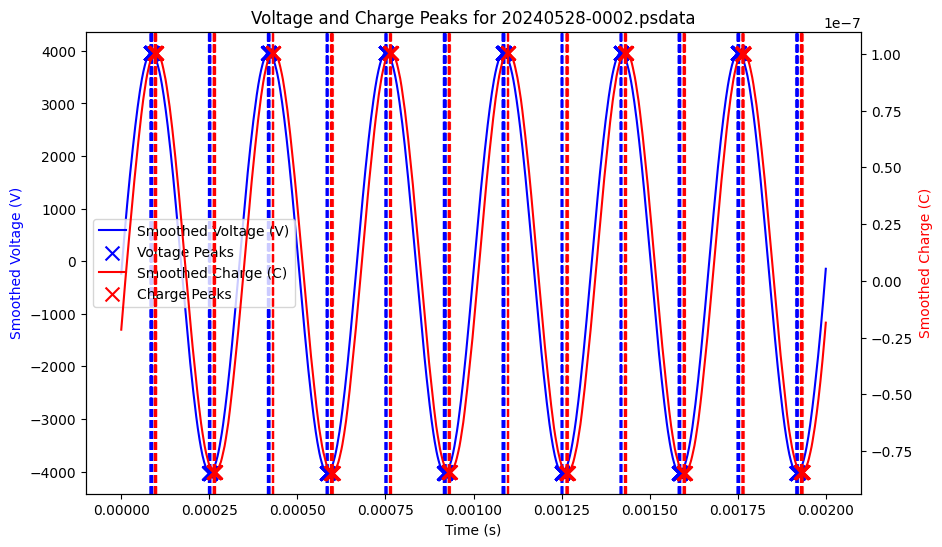

Average time delay: 0.0005433131082186234


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# Placeholder for results
time_delays = []

# Loop over each psdata file
for psdata_file_name, data_subset in data.groupby('psdata_file_name'):
    # Smooth the voltage and charge signals
    data_subset['voltage_smooth_V'] = savgol_filter(data_subset['voltage_V'], 20000, 2)
    data_subset['charge_smooth_C'] = savgol_filter(data_subset['charge_C'], 20000, 2)
    
    # Find peaks in the smoothed signals
    peaks_voltage, _ = find_peaks(data_subset['voltage_smooth_V'])
    peaks_charge, _ = find_peaks(data_subset['charge_smooth_C'])

    # Calculate time differences for each successive pair of peaks
    if len(peaks_voltage) > 1 and len(peaks_charge) > 1:
        for i in range(len(peaks_charge)):
            # Time of successive peaks for each signal
            peak_time_voltage = data_subset['time_s'].iloc[peaks_voltage[i]]
            peak_time_charge = data_subset['time_s'].iloc[peaks_charge[i]]
            
            # Calculate the time delay between the peaks of voltage and charge
            time_diff = peak_time_charge - peak_time_voltage
            time_delays.append(time_diff)
    else:
        time_delays.append(None)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plot smoothed voltage
    ax1.plot(data_subset['time_s'], data_subset['voltage_smooth_V'], label='Smoothed Voltage (V)', color='blue')
    ax1.scatter(data_subset['time_s'].iloc[peaks_voltage], data_subset['voltage_smooth_V'].iloc[peaks_voltage], color='blue', marker='x', s=100, label='Voltage Peaks')
    
    # Add vertical lines for voltage peaks
    for peak in peaks_voltage:
        ax1.axvline(data_subset['time_s'].iloc[peak], color='blue', linestyle='--', alpha=0.5)
    
    # Create a twin y-axis for the charge
    ax2 = ax1.twinx()
    
    # Plot smoothed charge
    ax2.plot(data_subset['time_s'], data_subset['charge_smooth_C'], label='Smoothed Charge (C)', color='red')
    ax2.scatter(data_subset['time_s'].iloc[peaks_charge], data_subset['charge_smooth_C'].iloc[peaks_charge], color='red', marker='x', s=100, label='Charge Peaks')
    
    # Add vertical lines for charge peaks
    for peak in peaks_charge:
        ax2.axvline(data_subset['time_s'].iloc[peak], color='red', linestyle='--', alpha=0.5)
    
    # Add titles and labels
    ax1.set_title(f'Voltage and Charge Peaks for {psdata_file_name}')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Smoothed Voltage (V)', color='blue')
    ax2.set_ylabel('Smoothed Charge (C)', color='red')
    
    # Create a combined legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='best')
    
    plt.show()

# Calculate the average time delay
if time_delays:
    # Remove None values
    time_delays = [td for td in time_delays if td is not None]
    if time_delays:
        average_time_delay = np.mean(time_delays)
    else:
        average_time_delay = None
else:
    average_time_delay = None

print(f"Average time delay: {average_time_delay}")